In [3]:
import os

In [8]:
os.chdir("/home/raufie/work/dynamics")

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
from pkg.integrators.forward_euler import forward_euler
from pkg.models.first_order.capactor import CapacitorModel

In [11]:
# dx/dt

In [12]:
def dxdt(xt):
    return 4*xt**2 - 16

In [13]:
C=1
V0=0
R=1

In [14]:
def dxdt(Qt, C=C, V0=V0, R=R):
    return (V0/R) - (Qt/(R*C))


In [15]:
xs = np.linspace(0, 5, 5)

In [16]:
linear_resistor_model = CapacitorModel(C=1, V0=2, R=1, k=3)

In [21]:
dxdt = lambda x: linear_resistor_model.charge_model_rhs(x)
# dxdt = lambda x: linear_resistor_model.discharge_model_rhs(x)

In [22]:
y_ul, y_ll = 13, -3

In [23]:
class OdeSolver:
    def plot_slope_field(self,dxdt,x1=0, x2=1, y1=0, y2=1, n=50, L=0.1):
        x_range = np.linspace(x1, x2, n)
        y_range = np.linspace(y1, y2, n)
        X, Y = np.meshgrid(x_range, y_range)
        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                x = X[i, j]
                y = Y[i, j]
                # 
                # h^2 = dx^2 + dy^2
                # h = sqrt(dx^2+dy^2)
                # find DT for length L
                # L^2 = (x2-x1)^2 + (y2-y1)^2
                # DT^2 + (m*DT)^2= L^2
                # DT^2(1+m^2) = L^2
                # DT(sqrt(1+m^2))=L
                # DT = L/sqrt(1+m^2)

                DT = L/np.sqrt(1+(dxdt(y)**2))
                x_next = x + DT
                y_next = y + dxdt(y) * DT
                plt.plot([x, x_next], [y, y_next], color='grey')

    def plot_solution(self,dxdt, x0, tn, dt=0.1):
        self.plot_slope_field(dxdt, x1=0, x2=10, y1=y_ll, y2=y_ul, n=20, L=0.2)
        for x in x0:
            data = forward_euler(x, dxdt, 10, dt=0.01)
            plt.plot(data[:,0],data[:,1], linewidth=2, label=f'x0={x}')

/home/raufie/work/dynamics/pkg/models/first_order/capactor.py:16: RuntimeWarning: invalid value encountered in scalar power
  return ((self.V0/self.R) - (Qt/(self.R*self.C)))**(1/self.k)


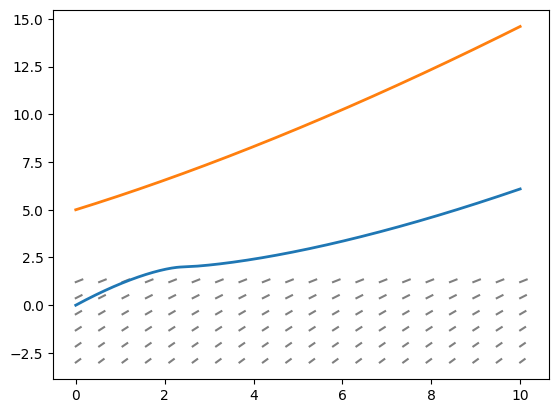

In [25]:
OdeSolver().plot_solution(dxdt, x0=[0,5], tn=10)

/tmp/ipykernel_2160/3284494722.py:13: RuntimeWarning: invalid value encountered in scalar power
  return -((Qt/(self.R*self.C)))**(1/self.k)


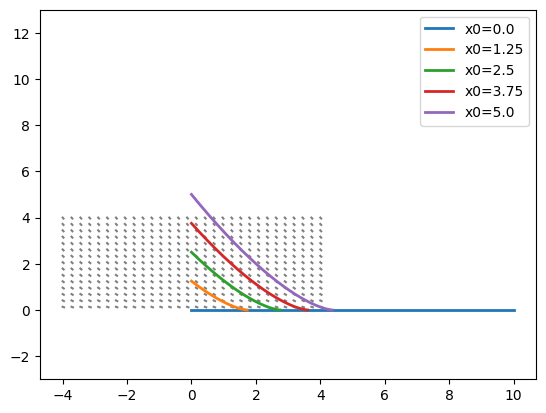

In [70]:
plot_slope_field(dxdt, x1=-4, x2=4, y1=-4, y2=4,n=30,L=0.05)

for x in xs:
    data = forward_euler(x, dxdt, 10, dt=0.01)
    plt.plot(data[:,0],data[:,1], linewidth=2, label=f'x0={x}')

plt.ylim(y_ll, y_ul)
plt.legend()

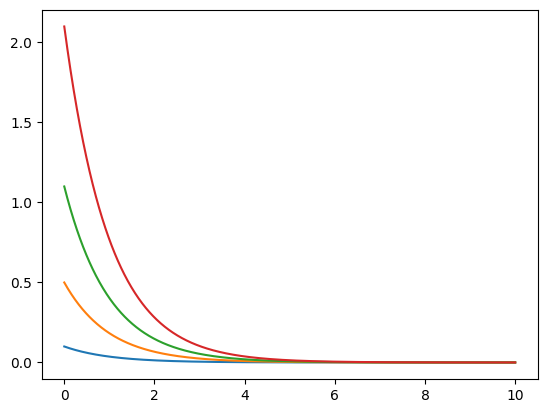

In [25]:
data = forward_euler(0.1, dxdt, 10, dt=0.01)
plt.plot(data[:,0],data[:,1])

data = forward_euler(0.5, dxdt, 10, dt=0.01)
plt.plot(data[:,0],data[:,1])

data = forward_euler(1.1, dxdt, 10, dt=0.01)
plt.plot(data[:,0],data[:,1])

data = forward_euler(2.1, dxdt, 10, dt=0.01)
plt.plot(data[:,0],data[:,1])

In [37]:
n_steps

10.0

In [21]:
xi

0.21600000000000003